# Linear Regression to Predict Hyperbolic Volume (Baseline)

In [2]:
import pandas as pd
from settings import *

In [3]:
knot_data = pd.read_csv(TRAIN_PATH)[['Name', 'PD Notation', 'Volume']]
knot_data.head()

,Name,PD Notation,Volume
0,4_1,[[4;2;5;1];[8;6;1;5];[6;3;7;4];[2;7;3;8]],2.029883
1,12n_242,[[1;5;2;4];[3;9;4;8];[16;6;17;5];[7;3;8;2];[18...,2.828122
2,5_2,[[1;5;2;4];[3;9;4;8];[5;1;6;10];[7;3;8;2];[9;7...,2.828122
3,6_1,[[1;7;2;6];[3;10;4;11];[5;3;6;2];[7;1;8;12];[9...,3.163963
4,7_2,[[2;10;3;9];[4;14;5;13];[6;12;7;11];[8;2;9;1];...,3.331744


In [4]:
link_data = pd.read_csv(TEST_PATH)[['Name', 'PD Notation', 'Volume']]
link_data.head()

,Name,PD Notation,Volume
0,4^2_1,[[5; 0; 6; 1]; [1; 6; 2; 7]; [7; 2; 4; 3]; [3;...,0.000000
1,5^2_1,[[7; 0; 8; 1]; [1; 4; 2; 5]; [9; 3; 6; 2]; [3;...,3.663862
2,6^2_1,[[0; 8; 1; 7]; [6; 2; 7; 1]; [2; 6; 3; 11]; [1...,0.000000
3,6^2_2,[[7; 0; 8; 1]; [1; 8; 2; 9]; [9; 2; 10; 3]; [3...,4.059766
4,6^2_3,[[9; 0; 10; 1]; [1; 6; 2; 7]; [5; 2; 6; 3]; [3...,5.333490


## Trivial Baseline

Incluides the following features for each knot projection:
- Crossing number.
- Number of faces.

In [5]:
import spherogram
import json
import numpy as np
import networkx as nx

In [6]:
def calculate_basic_features(row):
    link = spherogram.Link(json.loads(row['PD Notation'].replace(";",",")))
    row['n_crossings'] = int(len(link.crossing_entries())/2)
    row['n_faces'] = len(link.faces())
    row['writhe'] = link.writhe()
    row['is_alternating'] = link.is_alternating()

    graph = link.dual_graph().to_networkx()
    row['n_edges'] = graph.number_of_edges()
    row['n_nodes'] = graph.number_of_nodes()
    degrees = [degree for (node, degree) in graph.degree()]
    row['average_degree'] = np.mean(degrees)
    row['std_degrees'] = np.std(degrees)
    row['density'] = nx.density(graph)
    return row

In [7]:
knot_data = knot_data.apply(calculate_basic_features, axis = 1)
knot_data.head()

,Name,PD Notation,Volume,n_crossings,n_faces,writhe,is_alternating,n_edges,n_nodes,average_degree,std_degrees,density
0,4_1,[[4;2;5;1];[8;6;1;5];[6;3;7;4];[2;7;3;8]],2.029883,4,6,0,True,8,6,2.666667,0.471405,0.533333
1,12n_242,[[1;5;2;4];[3;9;4;8];[16;6;17;5];[7;3;8;2];[18...,2.828122,12,14,12,False,24,14,3.428571,2.381905,0.263736
2,5_2,[[1;5;2;4];[3;9;4;8];[5;1;6;10];[7;3;8;2];[9;7...,2.828122,5,7,5,True,10,7,2.857143,0.832993,0.476190
3,6_1,[[1;7;2;6];[3;10;4;11];[5;3;6;2];[7;1;8;12];[9...,3.163963,6,8,2,True,12,8,3.000000,1.224745,0.428571
4,7_2,[[2;10;3;9];[4;14;5;13];[6;12;7;11];[8;2;9;1];...,3.331744,7,9,7,True,14,9,3.111111,1.594744,0.388889


In [8]:
link_data = link_data.apply(calculate_basic_features, axis = 1)
link_data.head()

,Name,PD Notation,Volume,n_crossings,n_faces,writhe,is_alternating,n_edges,n_nodes,average_degree,std_degrees,density
0,4^2_1,[[5; 0; 6; 1]; [1; 6; 2; 7]; [7; 2; 4; 3]; [3;...,0.000000,4,6,-4,True,8,6,2.666667,0.942809,0.533333
1,5^2_1,[[7; 0; 8; 1]; [1; 4; 2; 5]; [9; 3; 6; 2]; [3;...,3.663862,5,7,-1,True,10,7,2.857143,0.638877,0.476190
2,6^2_1,[[0; 8; 1; 7]; [6; 2; 7; 1]; [2; 6; 3; 11]; [1...,0.000000,6,8,6,True,12,8,3.000000,1.732051,0.428571
3,6^2_2,[[7; 0; 8; 1]; [1; 8; 2; 9]; [9; 2; 10; 3]; [3...,4.059766,6,8,-6,True,12,8,3.000000,1.000000,0.428571
4,6^2_3,[[9; 0; 10; 1]; [1; 6; 2; 7]; [5; 2; 6; 3]; [3...,5.333490,6,8,-6,True,12,8,3.000000,0.866025,0.428571


### Take a Look at the Data

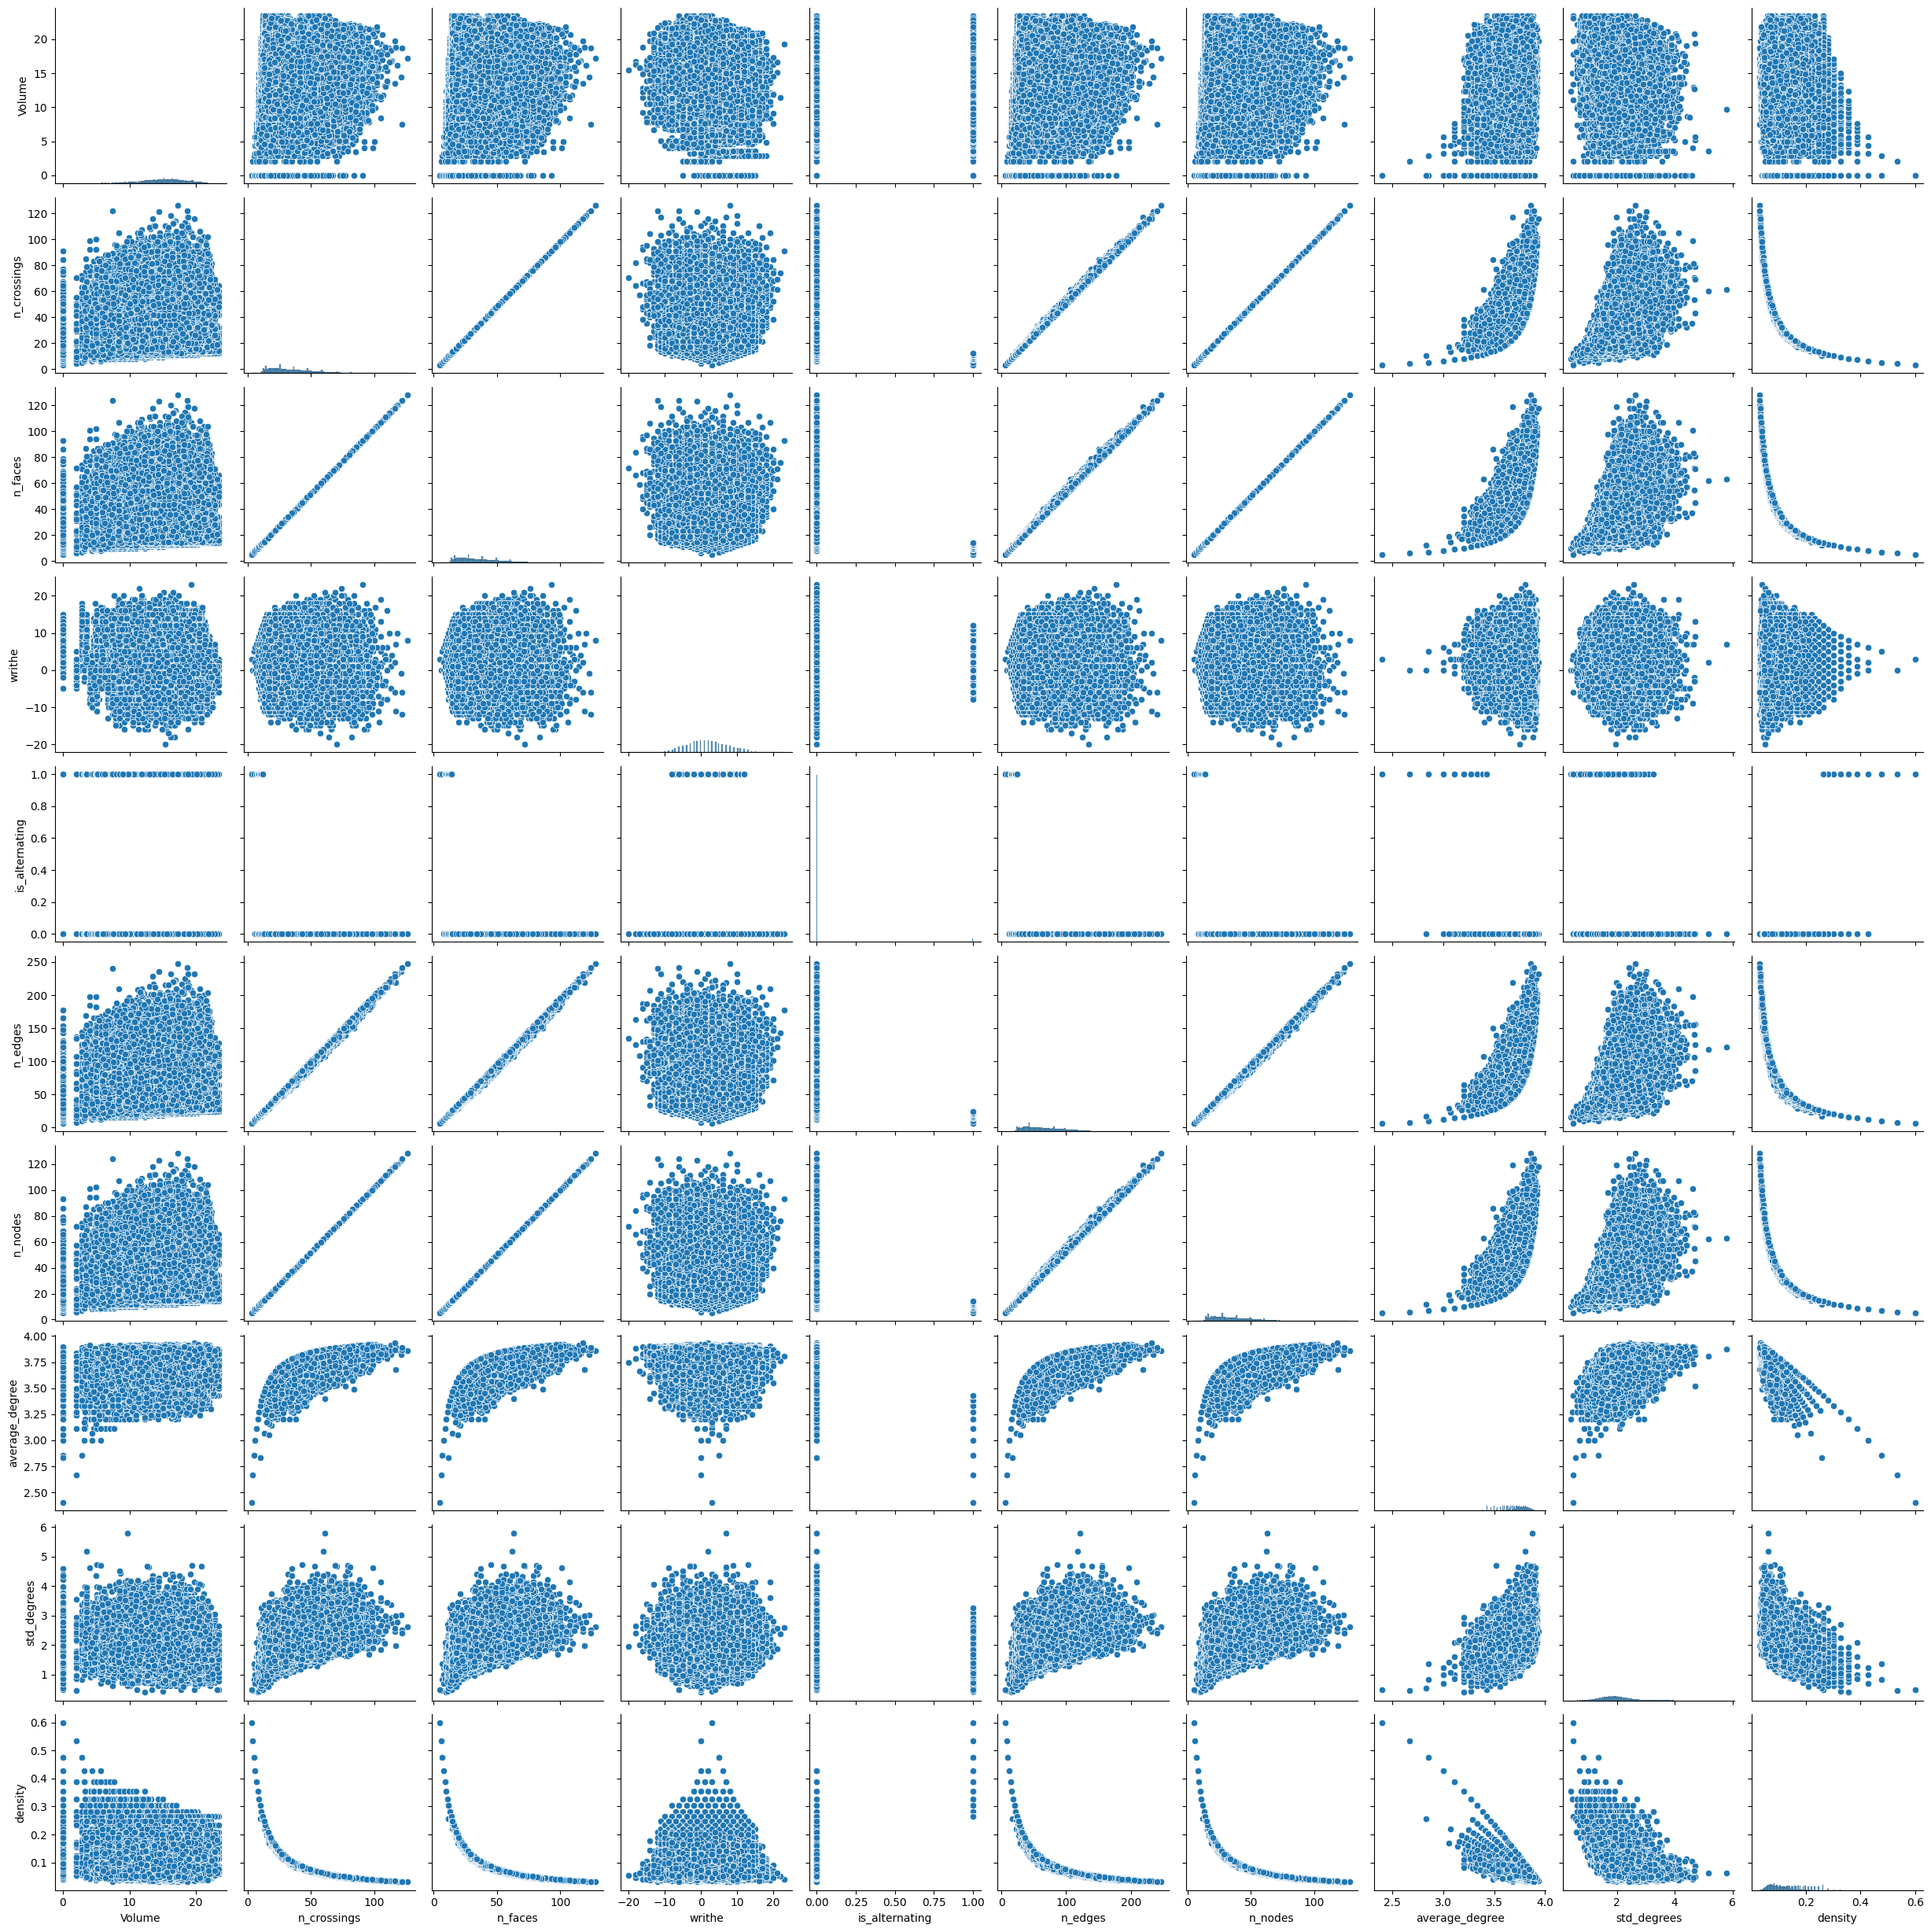

In [9]:
import seaborn as sns

sns.pairplot(knot_data.drop(['Name', 'PD Notation'], axis = 1))

In [10]:
#  Save data to avoid re-computation
knot_data.to_csv("datasets/knot_data_baselineB.csv")
link_data.to_csv("datasets/link_data_baselineB.csv")

### Scale Data

# Train test split

In [23]:
X = knot_data.drop(['Name', 'PD Notation', 'Volume'], axis = 1)
y = knot_data['Volume']

In [24]:
X_gen = link_data.drop(['Name', 'PD Notation', 'Volume'], axis = 1)
y_gen = link_data['Volume']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

## Train Model

In [26]:
# Import LinearRegression.
from sklearn.linear_model import LinearRegression

# Instantiate linear regression model.
model = LinearRegression()

In [27]:
# Fit the model to the training data.
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Evaluate Model

### Over Train Data

In [28]:
# Make predictions on the train data.
y_pred_train = model.predict(X_train)

In [29]:
# Import metrics.
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate and print R^2 score.
r2 = r2_score(y_train, y_pred_train)
print(f"R-squared: {r2:.4f}")

# Calculate and print MSE.
mae = mean_absolute_error(y_train, y_pred_train)
print(f"Mean absolute error: {mae:.4f}")

R-squared: 0.0764
Mean absolute error: 2.7526


### Over Test Data

In [30]:
# Make predictions on the testing data.
y_pred_test = model.predict(X_test)

In [31]:
# Import metrics.
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate and print R^2 score.
r2 = r2_score(y_test, y_pred_test)
print(f"R-squared: {r2:.4f}")

# Calculate and print MSE.
mae = mean_absolute_error(y_test, y_pred_test)
print(f"Mean absolute error: {mae:.4f}")

R-squared: 0.0723
Mean absolute error: 2.7489


### Over Link Data

In [32]:
# Make predictions on the generalization data.
y_pred_gen = model.predict(X_gen)

In [33]:
# Import metrics.
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate and print R^2 score.
r2 = r2_score(y_gen, y_pred_gen)
print(f"R-squared: {r2:.4f}")

# Calculate and print MSE.
mae = mean_absolute_error(y_gen, y_pred_gen)
print(f"Mean absolute error: {mae:.4f}")

R-squared: -1.6517
Mean absolute error: 4.4376


## Save Results

In [34]:
results = []

aux = pd.DataFrame()
aux['real'] = y_train
aux['expected'] = y_pred_train
aux['error'] = aux['expected'] - aux['real']
aux['set'] = 'train'
results.append(aux.copy())

aux = pd.DataFrame()
aux['real'] = y_test
aux['expected'] = y_pred_test
aux['error'] = aux['expected'] - aux['real']
aux['set'] = 'test'
results.append(aux.copy())

aux = pd.DataFrame()
aux['real'] = y_gen
aux['expected'] = y_pred_gen
aux['error'] = aux['expected'] - aux['real']
aux['set'] = 'test_gen'
results.append(aux.copy())

pd.concat(results, axis=0, ignore_index=True).to_csv("outputs/results-baselineB2.csv", index=False, float_format='%.15f')